In [213]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers
import random
print(f"Tensorflow: {tf.__version__}\nKeras: {keras.__version__}")

Tensorflow: 2.21.0
Keras: 3.13.2


In [214]:
(X_train, y_train),(X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [215]:
X_train.shape, y_train.shape

((60000, 28, 28), (60000,))

In [216]:
X_train.dtype, y_train.dtype

(dtype('uint8'), dtype('uint8'))

In [217]:
X_train.shape[1]

28

In [218]:
y_train[0]

np.uint8(9)

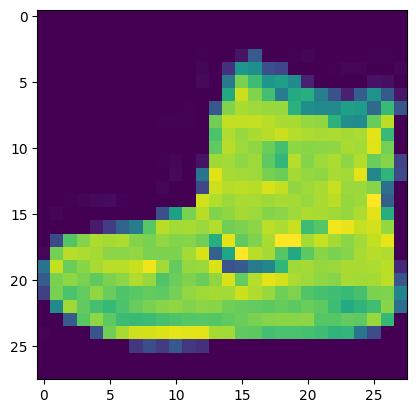

In [219]:
plt.imshow(X_train[0])

In [220]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_nums = len(class_names)
print(class_nums)

10


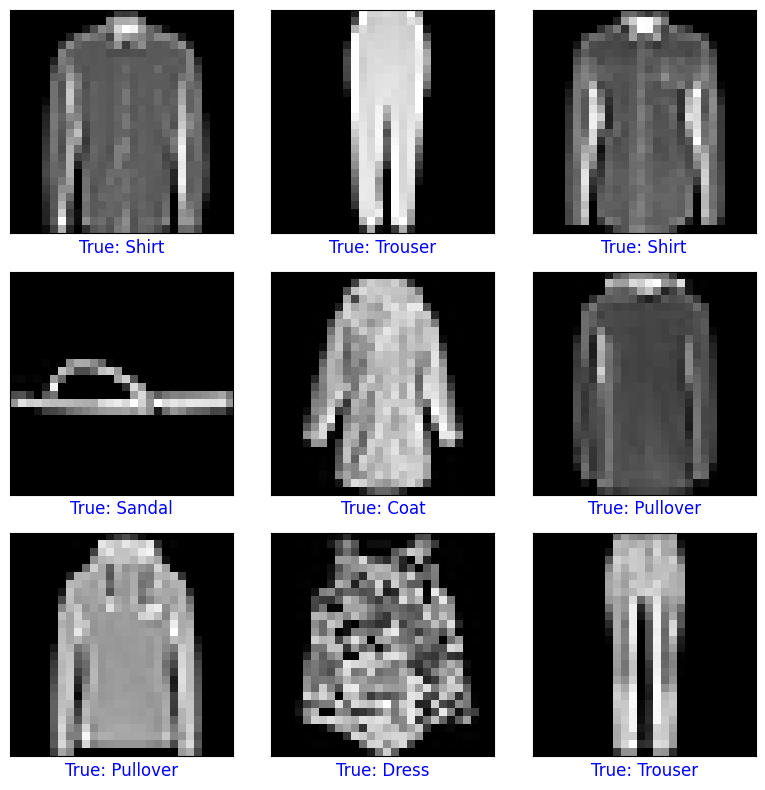

In [221]:
from typing import Optional
def plot_data(x_data: np.ndarray, y_data: np.ndarray, y_proba: Optional[np.ndarray] = None) -> None:
  nrows, ncols = 3,3
  fig, axes = plt.subplots(nrows, ncols, figsize=(8,8))
  len_x = x_data.shape[0]
  for idx in range(nrows*ncols):
    ax = axes[idx//ncols][idx%ncols]
    img_idx = random.randint(0, len_x)
    ax.imshow(x_data[img_idx], cmap='gray')
    #xoa cac dong tock
    ax.set(xticks=[],yticks=[])
    true_label_str = f"True: {class_names[y_data[img_idx]]}"
    #Optional
    color = 'blue'
    if y_proba is not None:
      predicted_idx = np.argmax(y_proba[img_idx])
      prediction_label = class_names[predicted_idx]
      color = 'red' if predicted_idx != y_data[img_idx] else color
      predicted_label_str = f"\nPredicted: {prediction_label}"

    img_title = true_label_str if y_proba is None else true_label_str + predicted_label_str
    #

    ax.set_xlabel(img_title,color=color, fontsize = 12)
  #Cho gon hon
  plt.tight_layout()
  plt.show()
plot_data(X_train, y_train)

Image Pre-processing

In [222]:
X_train = X_train.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255

In [223]:
X_test.shape, X_test.dtype

((10000, 28, 28), dtype('float32'))

In [224]:
X_train = np.expand_dims(X_train, axis=-1)

In [225]:
X_train.shape

(60000, 28, 28, 1)

In [226]:
X_test = np.expand_dims(X_test, axis=-1)

In [227]:
X_test.shape

(10000, 28, 28, 1)

Build neural network

In [228]:
y_train_label = keras.utils.to_categorical(y_train, class_nums)
y_test_label = keras.utils.to_categorical(y_test, class_nums)

In [229]:
y_train[0], y_train_label[0]

(np.uint8(9), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]))

In [230]:
model = keras.models.Sequential([
    layers.Flatten(input_shape=[28,28,1]),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(class_nums, activation='softmax')
])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [231]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [202]:
epochs = 10
history = model.fit(X_train, y_train_label, epochs=epochs, batch_size=256, validation_split=0.1)

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7709 - loss: 0.6359 - val_accuracy: 0.8318 - val_loss: 0.4559
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8459 - loss: 0.4173 - val_accuracy: 0.8582 - val_loss: 0.3854
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8641 - loss: 0.3650 - val_accuracy: 0.8695 - val_loss: 0.3609
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8759 - loss: 0.3328 - val_accuracy: 0.8813 - val_loss: 0.3266
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8840 - loss: 0.3078 - val_accuracy: 0.8790 - val_loss: 0.3440
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8915 - loss: 0.2882 - val_accuracy: 0.8725 - val_loss: 0.3437
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8959 - loss: 0.2737 - val_accuracy: 0.8798 - val_loss: 0.3469
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9021 - loss: 0.2579 - val_accuracy: 0

In [203]:
history_dict = history.history

In [204]:
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [205]:
train_loss, val_loss = history_dict['loss'], history_dict['val_loss']
train_acc, val_acc = history_dict['accuracy'], history_dict['val_accuracy']

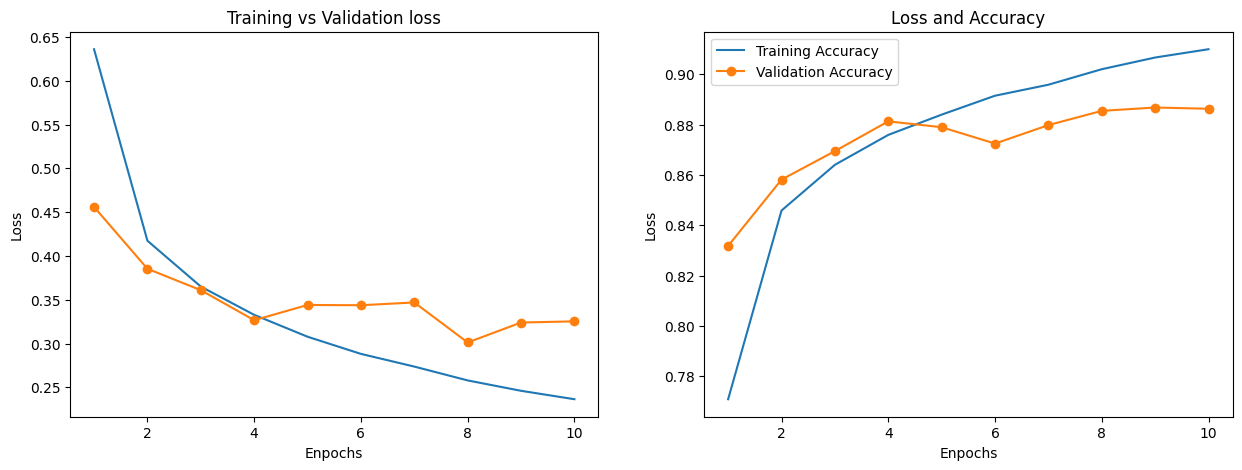

In [206]:
fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
epoch_runs = [i+1 for i in range(epochs)]
ax1.plot(epoch_runs, train_loss, label='Training loss')
ax1.plot(epoch_runs, val_loss, label='Validation loss', marker='o')
ax1.set(title='Training vs Validation loss',xlabel='Enpochs', ylabel='Loss')

ax2.plot(epoch_runs, train_acc, label='Training Accuracy')
ax2.plot(epoch_runs, val_acc, label='Validation Accuracy', marker='o')
ax2.set(title='Loss and Accuracy',xlabel='Enpochs', ylabel='Loss')
plt.legend()
plt.show()


Model Evaluation

In [207]:
score = model.evaluate(X_test, y_test_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8797 - loss: 0.3433


In [208]:
print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

Test loss: 0.3433
Test accuracy: 0.8797


Prediction


In [209]:
X_sample = X_test[:3]
y_proba = model.predict(X_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


In [210]:
y_proba.round(3)

array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.007, 0.   ,
        0.993],
       [0.   , 0.   , 0.998, 0.   , 0.001, 0.   , 0.001, 0.   , 0.   ,
        0.   ],
       [0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ]], dtype=float32)

In [211]:
predictions = np.argmax(y_proba, axis=1)

In [212]:
[class_names[pred] for pred in predictions]

['Ankle boot', 'Pullover', 'Trouser']

In [233]:
y_proba = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


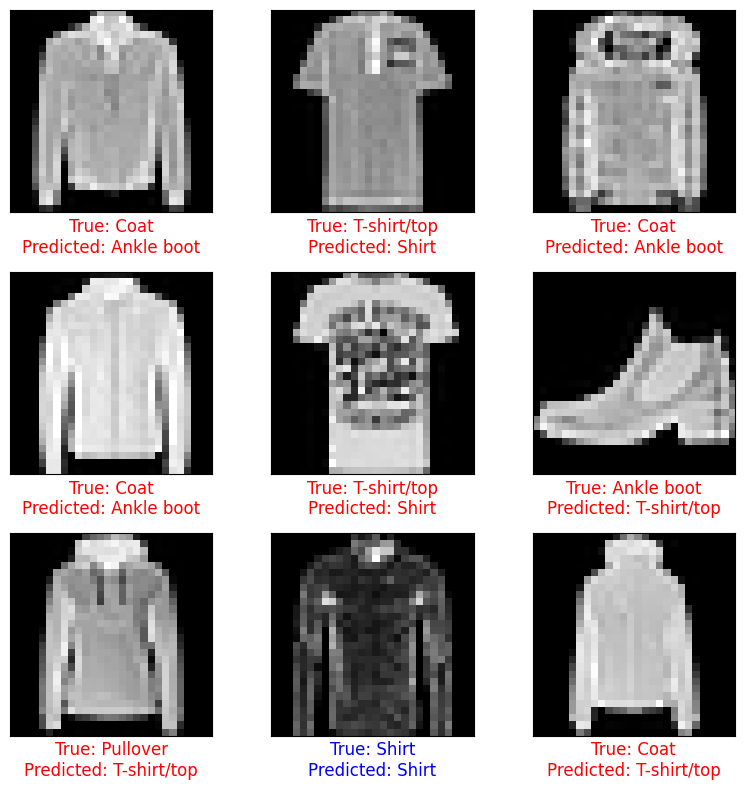

In [238]:
plot_data(X_test, y_test, y_proba)